7) Create a data frame containing information about proteins that interact with specific drugs. These proteins are known as targets. The data frame should include at least the DrugBank ID of the target, information about the external database (source, e.g., Swiss-Prot), the identifier in the external database, the polypeptide name, the name of the gene encoding the polypeptide, the GenAtlas gene ID, the chromosome number, and the cellular localization.

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

# Define the file path and namespace
file_path = 'drugbank_partial.xml'
namespace = {'drugbank': 'http://www.drugbank.ca'}
data = []

# Parse the XML file and extract relevant information
for event, elem in ET.iterparse(file_path, events=('start', 'end')):
    if elem.tag == f"{{{namespace['drugbank']}}}target" and event == 'end':
        target_dict = {}
        target_dict['id'] = elem.find('drugbank:id', namespace).text
        target_dict['name'] = elem.find('drugbank:name', namespace).text

        # Extract polypeptide information
        polypeptide = elem.find('drugbank:polypeptide', namespace)
        if polypeptide is not None:
            target_dict['source'] = polypeptide.get('source')
            target_dict['source-id'] = polypeptide.get('id')
            target_dict['gene-name'] = polypeptide.find('drugbank:gene-name', namespace).text
            target_dict['genatlas-id'] = None

            # Extract GenAtlas ID if available
            for external_identifier in polypeptide.findall('.//drugbank:external-identifier', namespace):
                if external_identifier.find('drugbank:resource', namespace).text == 'GenAtlas':
                    target_dict['genatlas-id'] = external_identifier.find('drugbank:identifier', namespace).text

            target_dict['chromosome-location'] = polypeptide.find('drugbank:chromosome-location', namespace).text
            target_dict['cellular-location'] = polypeptide.find('drugbank:cellular-location', namespace).text
        data.append(target_dict)
        elem.clear()

# Create a DataFrame from the extracted data
df = pd.DataFrame(data)
df

,id,name,source,source-id,gene-name,genatlas-id,chromosome-location,cellular-location
0,BE0000048,Prothrombin,Swiss-Prot,P00734,F2,F2,11,Secreted
1,BE0000767,Epidermal growth factor receptor,Swiss-Prot,P00533,EGFR,EGFR,7,Cell membrane
2,BE0000901,Low affinity immunoglobulin gamma Fc region re...,Swiss-Prot,O75015,FCGR3B,FCGR3B,1,Cell membrane
3,BE0002094,Complement C1q subcomponent subunit A,Swiss-Prot,P02745,C1QA,C1QA,1,Secreted
4,BE0002095,Complement C1q subcomponent subunit B,Swiss-Prot,P02746,C1QB,C1QB,1,Secreted
...,...,...,...,...,...,...,...,...
262,BE0000844,Oxytocin receptor,Swiss-Prot,P30559,OXTR,OXTR,3,Cell membrane
263,BE0000590,Integrin alpha-4,Swiss-Prot,P13612,ITGA4,ITGA4,2,Membrane
264,BE0000901,Low affinity immunoglobulin gamma Fc region re...,Swiss-Prot,O75015,FCGR3B,FCGR3B,1,Cell membrane
265,BE0000710,High affinity immunoglobulin gamma Fc receptor I,Swiss-Prot,P12314,FCGR1A,FCGR1A,1,Cell membrane


8) Create a pie chart showing the percentage distribution of targets in different cellular locations.

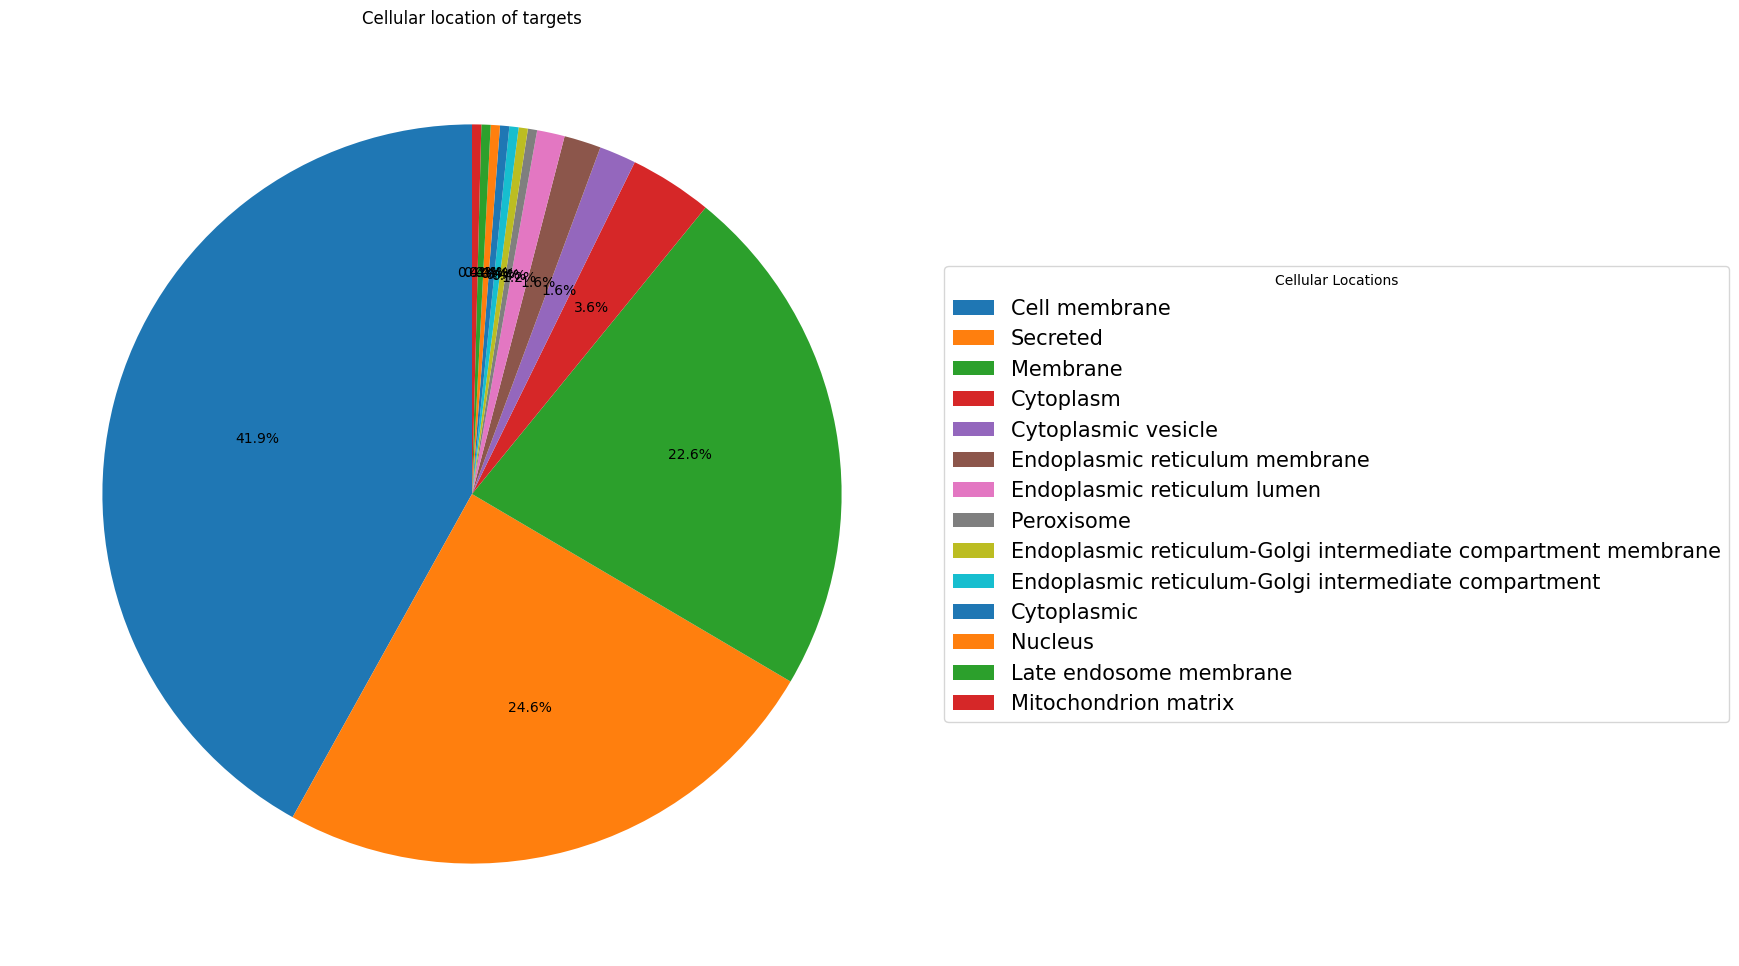

In [4]:
# Count the occurrences of each cellular location
cellular_location_counts = df['cellular-location'].value_counts()

# Plot a pie chart of the cellular locations
plt.figure(figsize=(12, 12))
plt.pie(cellular_location_counts, autopct='%1.1f%%', startangle=90)

plt.legend(cellular_location_counts.index, title="Cellular Locations", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=15)
plt.title('Cellular location of targets')
plt.show()